In [ ]:
# Install dependencies (uncomment if running in a fresh environment e.g. Colab/Kaggle)
# !pip install -q pandas numpy scikit-learn matplotlib seaborn torch pytorch-tabnet tabpfn


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


Load data

In [2]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [9]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [10]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


Exploratory Data Analysis(EDA)

In [13]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values.")

# Duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Unique CustomerId check
print(f"Unique CustomerId count: {df['CustomerId'].nunique()} / {len(df)}")


Missing values per column:
No missing values.

Duplicate rows: 0
Unique CustomerId count: 10000 / 10000


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


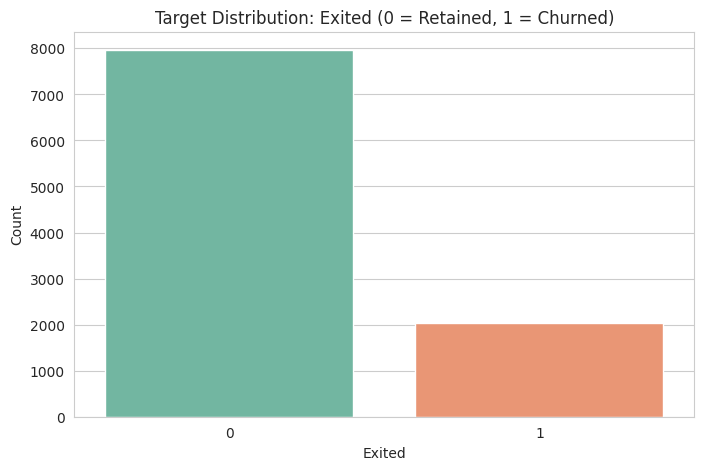

In [14]:
# Target distribution
target_counts = df["Exited"].value_counts(normalize=True) * 100
print(target_counts)

plt.figure()
sns.countplot(x="Exited", data=df, palette="Set2")
plt.title("Target Distribution: Exited (0 = Retained, 1 = Churned)")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()


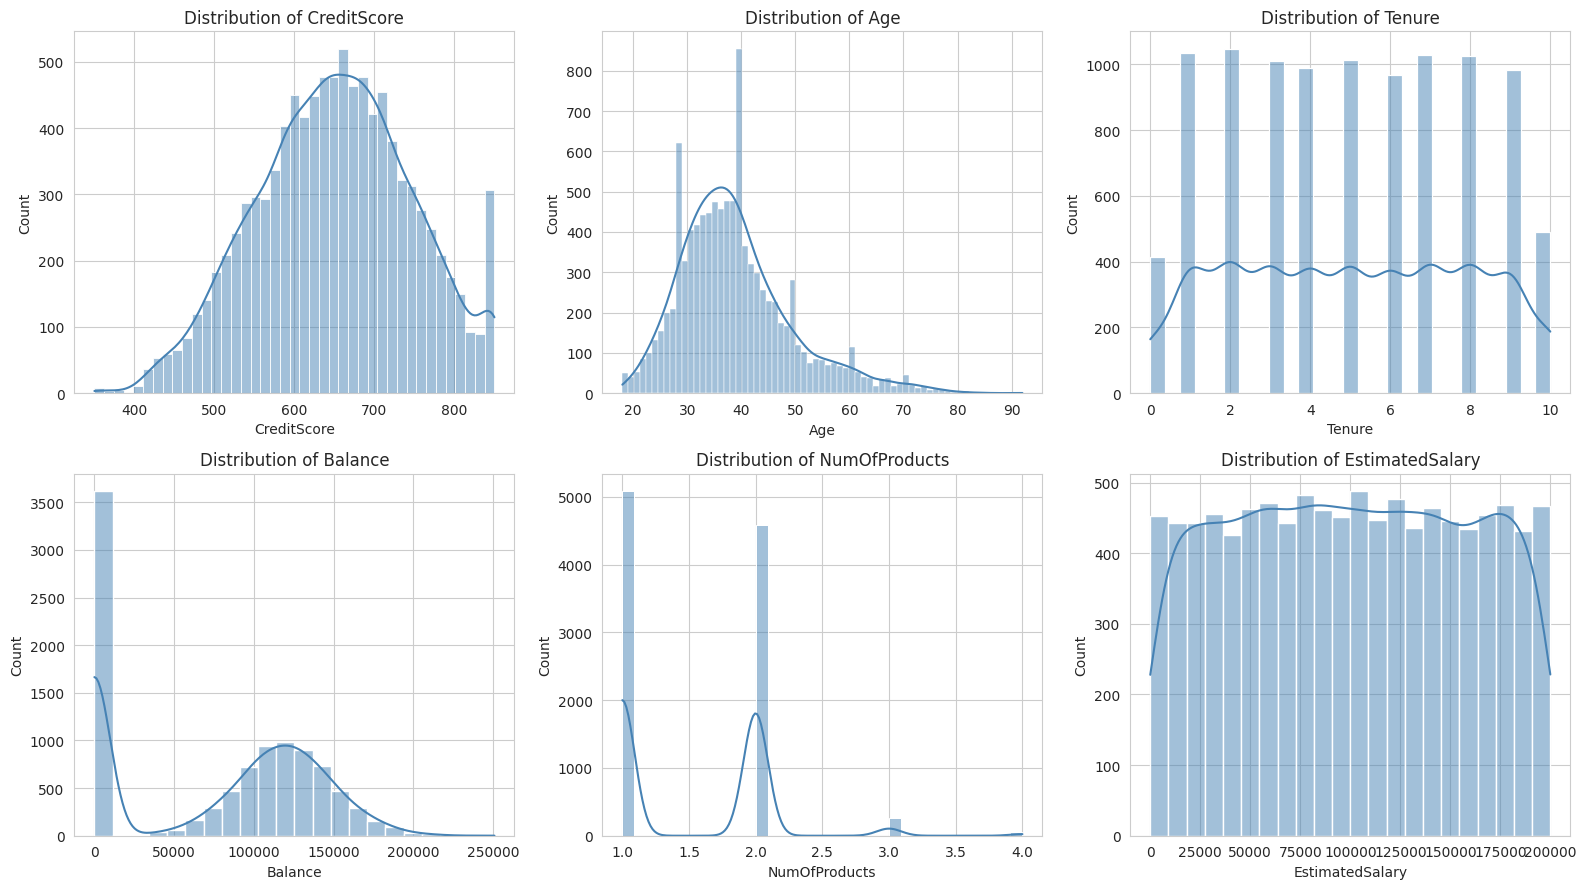

In [ ]:
# Numeric feature distributions
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


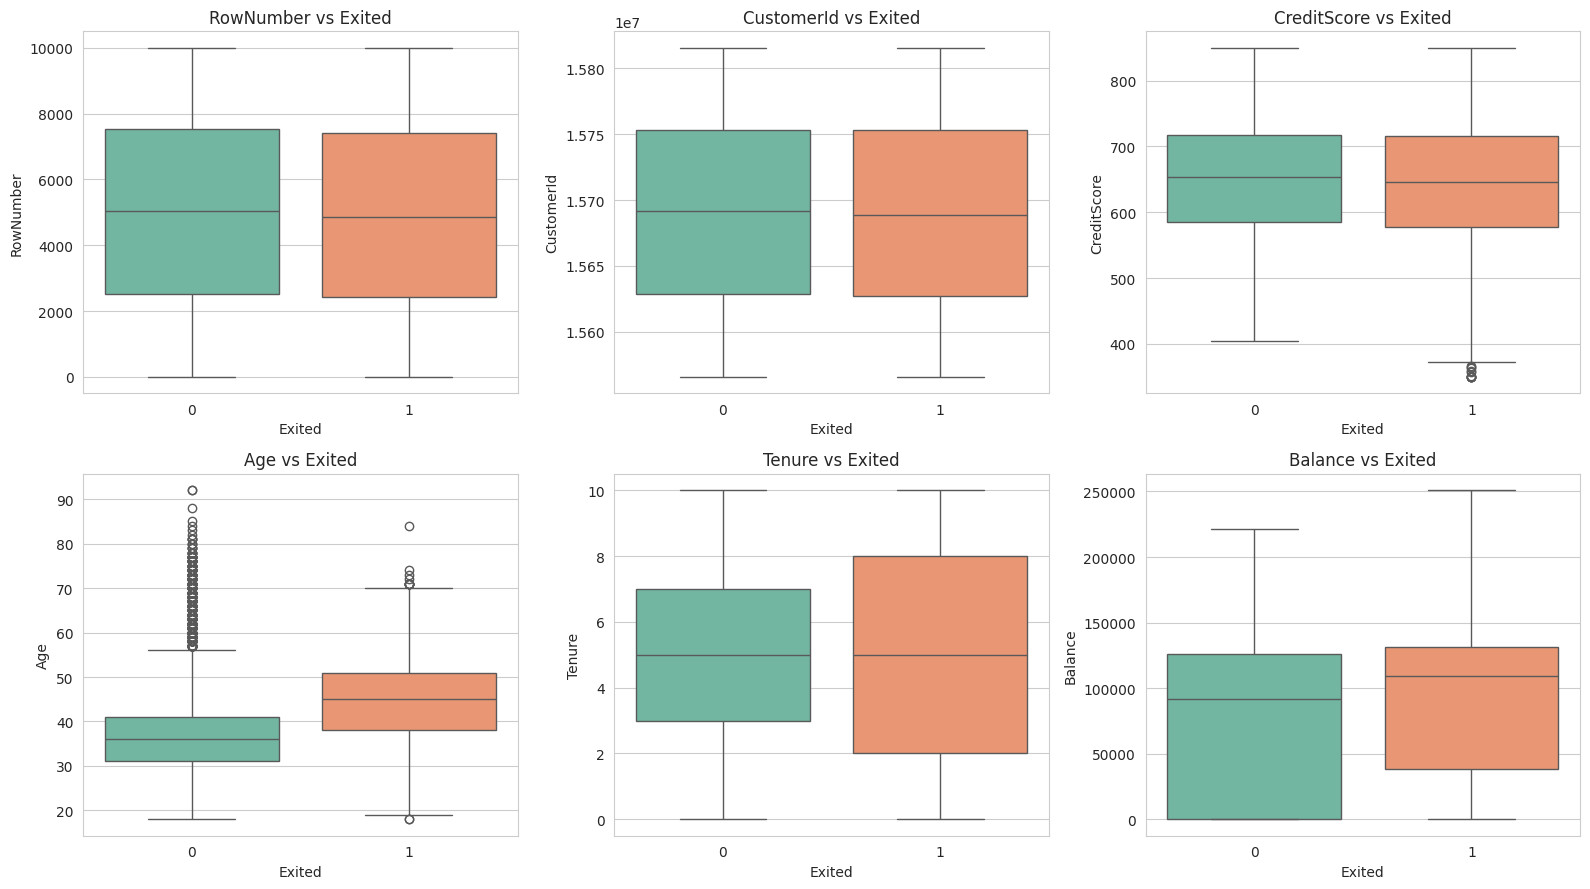

In [17]:
# Numeric features vs churn (boxplots)
numeric_cols = df.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} vs Exited")

plt.tight_layout()
plt.show()

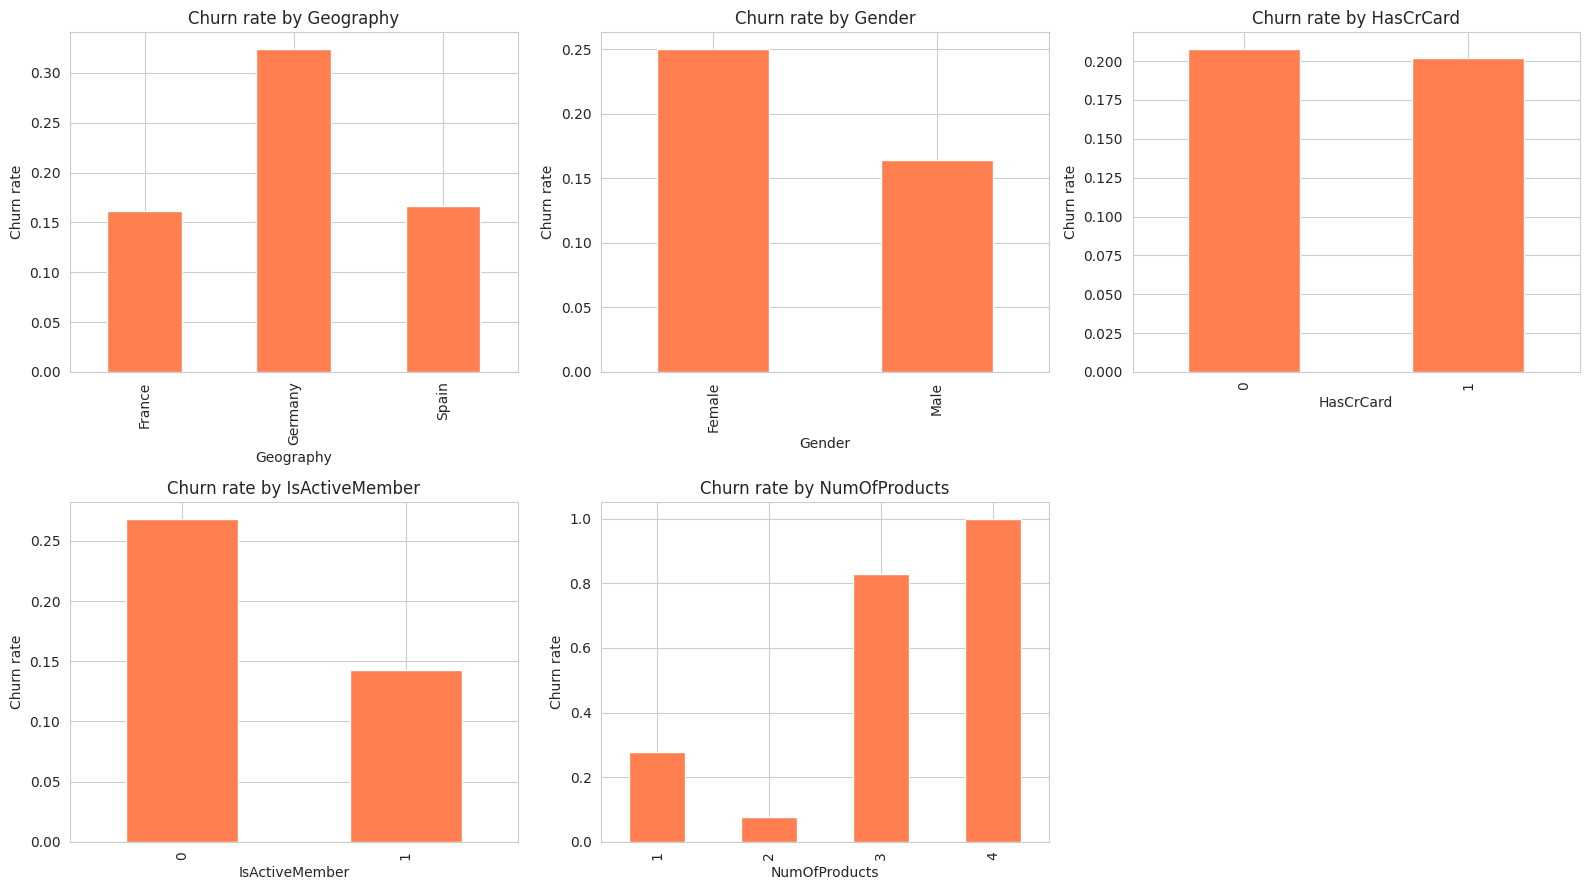

In [18]:
# Categorical features vs churn
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_cols):
    churn_rate = df.groupby(col)["Exited"].mean().sort_index()
    churn_rate.plot(kind="bar", ax=ax, color="coral")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


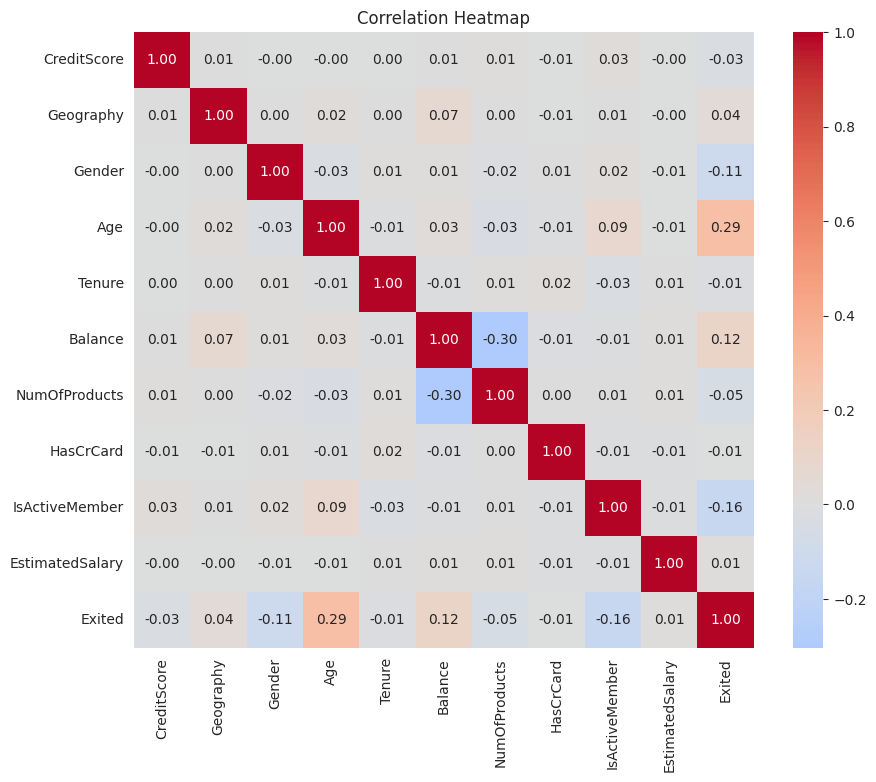

In [19]:
# Correlation heatmap (numeric + encoded target)
corr_df = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()
corr_df["Geography"] = LabelEncoder().fit_transform(corr_df["Geography"])
corr_df["Gender"] = LabelEncoder().fit_transform(corr_df["Gender"])

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


Preprocesssing

In [20]:
data = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()

# Encode Gender (binary)
le_gender = LabelEncoder()
data["Gender"] = le_gender.fit_transform(data["Gender"])  # Female=0, Male=1

# One-hot encode Geography
data = pd.get_dummies(data, columns=["Geography"], drop_first=True)

data.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [21]:
X = data.drop(columns=["Exited"])
y = data["Exited"]

feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Features (11): ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
Train shape: (8000, 11), Test shape: (2000, 11)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

y_train_arr = y_train.values
y_test_arr = y_test.values

# TabNet/TabPFN expect numpy arrays
X_train_np = X_train_scaled
X_test_np = X_test_scaled


In [23]:
# Helper to evaluate & compare models consistently
results = {}

def evaluate_model(name, y_true, y_pred, y_proba):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }
    results[name] = metrics

    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Retained", "Churned"]))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
    plt.title(f"{name} — Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    return metrics


Model 01 - Tabnet

In [24]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.2 MB/s eta 0:00:00


In [25]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet_clf = TabNetClassifier(
    n_d=16, n_a=16, n_steps=5, gamma=1.5,
    seed=RANDOM_STATE, verbose=1,
)

tabnet_clf.fit(
    X_train=X_train_np, y_train=y_train_arr,
    eval_set=[(X_test_np, y_test_arr)],
    eval_name=["valid"], eval_metric=["auc"],
    max_epochs=100, patience=15,
    batch_size=256, virtual_batch_size=128,
)


epoch 0  | loss: 0.55755 | valid_auc: 0.68935 |  0:00:02s
epoch 1  | loss: 0.43568 | valid_auc: 0.77381 |  0:00:03s
epoch 2  | loss: 0.42574 | valid_auc: 0.80849 |  0:00:04s
epoch 3  | loss: 0.40844 | valid_auc: 0.80296 |  0:00:05s
epoch 4  | loss: 0.39103 | valid_auc: 0.80169 |  0:00:06s
epoch 5  | loss: 0.38845 | valid_auc: 0.80809 |  0:00:08s
epoch 6  | loss: 0.38633 | valid_auc: 0.82266 |  0:00:09s
epoch 7  | loss: 0.38233 | valid_auc: 0.80797 |  0:00:11s
epoch 8  | loss: 0.3794  | valid_auc: 0.82275 |  0:00:12s
epoch 9  | loss: 0.36988 | valid_auc: 0.80597 |  0:00:13s
epoch 10 | loss: 0.37213 | valid_auc: 0.83094 |  0:00:14s
epoch 11 | loss: 0.37095 | valid_auc: 0.81811 |  0:00:15s
epoch 12 | loss: 0.37507 | valid_auc: 0.83049 |  0:00:16s
epoch 13 | loss: 0.37061 | valid_auc: 0.82025 |  0:00:18s
epoch 14 | loss: 0.37603 | valid_auc: 0.81737 |  0:00:19s
epoch 15 | loss: 0.36501 | valid_auc: 0.83819 |  0:00:20s
epoch 16 | loss: 0.36738 | valid_auc: 0.82778 |  0:00:22s
epoch 17 | los

--- TabNet ---
Accuracy: 0.8605
Precision: 0.7319
Recall: 0.4963
F1: 0.5915
ROC-AUC: 0.8489

              precision    recall  f1-score   support

    Retained       0.88      0.95      0.92      1593
     Churned       0.73      0.50      0.59       407

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



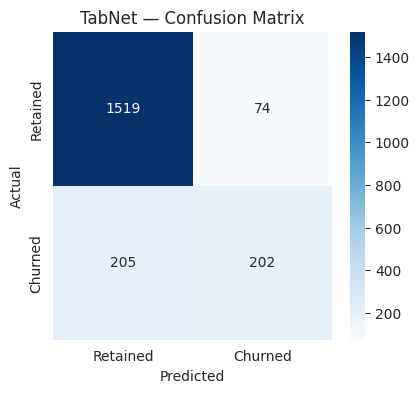

In [26]:
tabnet_pred = tabnet_clf.predict(X_test_np)
tabnet_proba = tabnet_clf.predict_proba(X_test_np)[:, 1]

tabnet_metrics = evaluate_model("TabNet", y_test_arr, tabnet_pred, tabnet_proba)


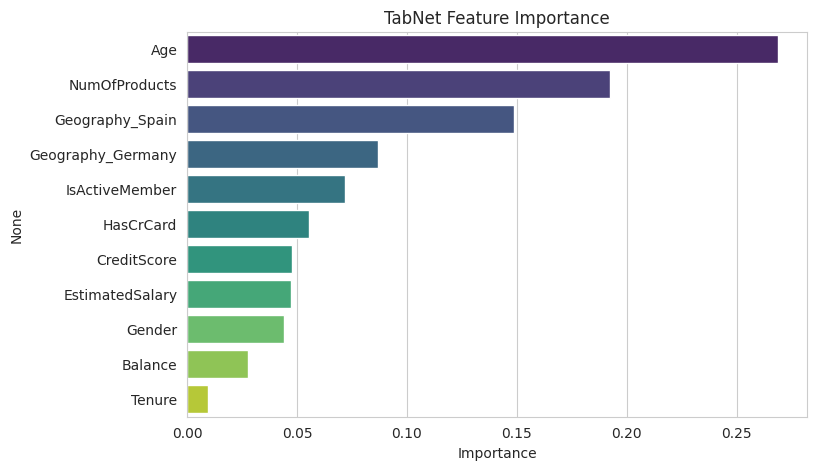

In [27]:
# TabNet feature importance
importances = pd.Series(tabnet_clf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure()
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("TabNet Feature Importance")
plt.xlabel("Importance")
plt.show()


Model 02 - TabPFN

In [28]:
import sys
!{sys.executable} -m pip install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.7 MB/s eta 0:00:00


In [29]:
import os

os.environ["TABPFN_TOKEN"] = "tabpfn_sk_SFdEkBPD9MTHBWtEOFyGSE5nvtnkbfJLD_cIvdUrJtg"

In [30]:
token = os.environ.get("TABPFN_TOKEN", "")

print("Token exists:", bool(token))
print("Token length:", len(token))
print("Contains non-ASCII:", any(ord(c) > 127 for c in token))
print("Contains ellipsis:", "…" in token)

Token exists: True
Token length: 53
Contains non-ASCII: False
Contains ellipsis: False


In [31]:
from tabpfn import TabPFNClassifier

tabpfn_clf = TabPFNClassifier(
    device="cpu",
    random_state=RANDOM_STATE,
    ignore_pretraining_limits=True
)

tabpfn_clf.fit(
    X_train_np,
    y_train_arr
)

tabpfn-v3-classifier-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  213MB            

tabpfn-v3-classifier-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

TabPFNClassifier(device='cpu', ignore_pretraining_limits=True, random_state=42)

--- TabPFN ---
Accuracy: 0.8700
Precision: 0.7774
Recall: 0.5061
F1: 0.6131
ROC-AUC: 0.8790

              precision    recall  f1-score   support

    Retained       0.88      0.96      0.92      1593
     Churned       0.78      0.51      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



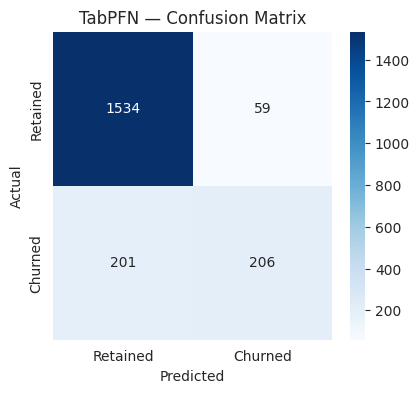

In [32]:
tabpfn_pred = tabpfn_clf.predict(X_test_np)
tabpfn_proba = tabpfn_clf.predict_proba(X_test_np)[:, 1]

tabpfn_metrics = evaluate_model("TabPFN", y_test_arr, tabpfn_pred, tabpfn_proba)


Model Comparison

In [33]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
TabNet,0.8605,0.731884,0.496314,0.591508,0.848914
TabPFN,0.8700,0.777358,0.506143,0.613095,0.878968


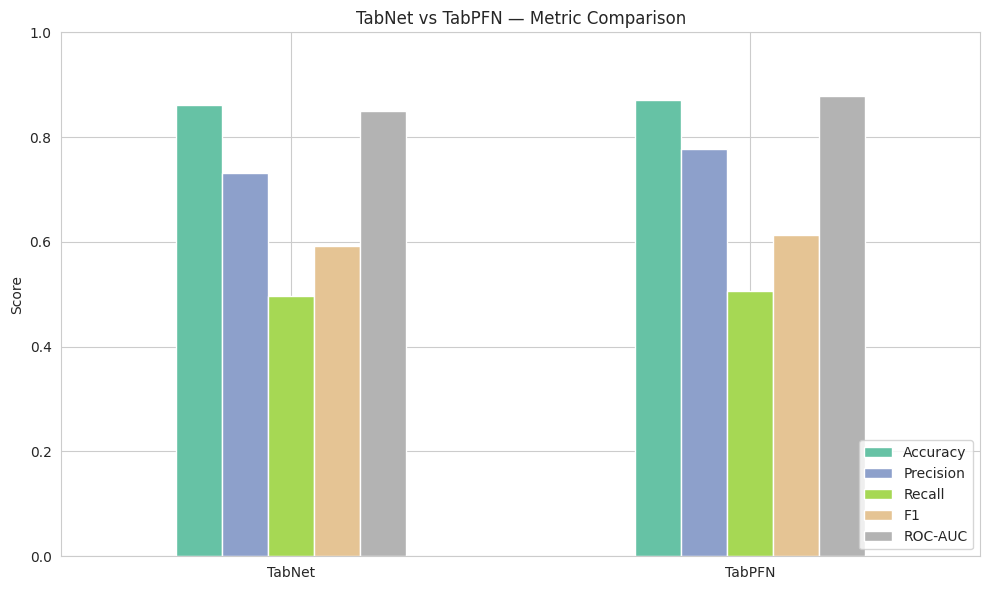

In [34]:
results_df.plot(kind="bar", figsize=(10, 6), colormap="Set2")
plt.title("TabNet vs TabPFN — Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


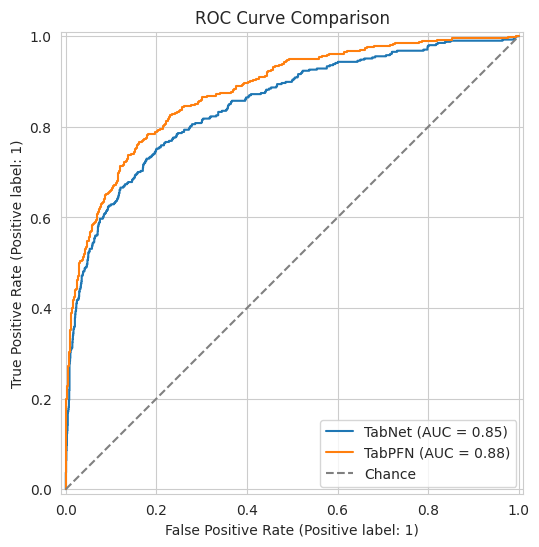

In [35]:
# ROC curves side by side
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test_arr, tabnet_proba, name="TabNet", ax=ax)
RocCurveDisplay.from_predictions(y_test_arr, tabpfn_proba, name="TabPFN", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()
